In [22]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [3]:
df = pd.read_csv("Credit.csv")
df.head()

,ID,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,1,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,2,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,3,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,4,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,5,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


In [4]:
df.describe()

,ID,Income,Limit,Rating,Cards,Age,Education,Balance
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,45.218885,4735.600000,354.940000,2.957500,55.667500,13.450000,520.015000
std,115.614301,35.244273,2308.198848,154.724143,1.371275,17.249807,3.125207,459.758877
min,1.000000,10.354000,855.000000,93.000000,1.000000,23.000000,5.000000,0.000000
25%,100.750000,21.007250,3088.000000,247.250000,2.000000,41.750000,11.000000,68.750000
50%,200.500000,33.115500,4622.500000,344.000000,3.000000,56.000000,14.000000,459.500000
75%,300.250000,57.470750,5872.750000,437.250000,4.000000,70.000000,16.000000,863.000000
max,400.000000,186.634000,13913.000000,982.000000,9.000000,98.000000,20.000000,1999.000000


In [5]:
df = df.dropna()

df["Student"] = df["Student"].str.strip()
df["Married"] = df["Married"].str.strip()
df["Gender"] = df["Gender"].str.strip()

df["Student_num"] = df["Student"].map({"No": 0, "Yes": 1})
df["Married_num"] = df["Married"].map({"No": 0, "Yes": 1})
df["Gender_num"] = df["Gender"].map({"Male": 0, "Female": 1})

df = pd.get_dummies(df, columns=["Ethnicity"], drop_first=True)
df = df.drop(columns=["Student", "Married", "Gender"])

In [6]:
df.head()

,ID,Income,Limit,Rating,Cards,Age,Education,Balance,Student_num,Married_num,Gender_num,Ethnicity_Asian,Ethnicity_Caucasian
0,1,14.891,3606,283,2,34,11,333,0,1,0,False,True
1,2,106.025,6645,483,3,82,15,903,1,1,1,True,False
2,3,104.593,7075,514,4,71,11,580,0,0,0,True,False
3,4,148.924,9504,681,3,36,11,964,0,0,1,True,False
4,5,55.882,4897,357,2,68,16,331,0,1,0,False,True


In [8]:
poly = PolynomialFeatures(degree=2, include_bias=False)
y = df["Balance"]
X_raw = df.drop(columns=["Balance"])
X = poly.fit_transform(X_raw)
feature_names = poly.get_feature_names_out(X_raw.columns)
X = pd.DataFrame(X, columns=feature_names)
X.head()


,ID,Income,Limit,Rating,Cards,Age,Education,Student_num,Married_num,Gender_num,...,Married_num^2,Married_num Gender_num,Married_num Ethnicity_Asian,Married_num Ethnicity_Caucasian,Gender_num^2,Gender_num Ethnicity_Asian,Gender_num Ethnicity_Caucasian,Ethnicity_Asian^2,Ethnicity_Asian Ethnicity_Caucasian,Ethnicity_Caucasian^2
0,1.0,14.891,3606.0,283.0,2.0,34.0,11.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2.0,106.025,6645.0,483.0,3.0,82.0,15.0,1.0,1.0,1.0,...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
2,3.0,104.593,7075.0,514.0,4.0,71.0,11.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,4.0,148.924,9504.0,681.0,3.0,36.0,11.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
4,5.0,55.882,4897.0,357.0,2.0,68.0,16.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [9]:
lambdas = np.logspace(-4, 2, 100)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso_cv", LassoCV(alphas=lambdas, cv=5, random_state=42, max_iter=10000))
])

model.fit(X, y)

best_lambda = model.named_steps["lasso_cv"].alpha_
best_coefficients = model.named_steps["lasso_cv"].coef_
best_intercept = model.named_steps["lasso_cv"].intercept_

print("Best lambda:", best_lambda)
print("Intercept:", best_intercept)
print("Coefficients:", best_coefficients)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:614: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7570.405493570142, tolerance: 6884.9098
  model = cd_fast.enet_coordinate_descent_gram(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:614: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 10041.28214679996, tolerance: 6884.9098
  model = cd_fast.enet_coordinate_descent_gram(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:614: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 12061.706922842423, tolerance: 6884.9098
  model = cd_fast.enet_coordinate_descent_gram(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:614: ConvergenceWarning: Objec

Best lambda: 0.32745491628777285
Intercept: 520.015
Coefficients: [ 0.00000000e+00 -0.00000000e+00  2.44002444e+01  1.34655308e+02
  0.00000000e+00  0.00000000e+00  0.00000000e+00  2.20883060e+01
  6.81293495e+00 -0.00000000e+00  0.00000000e+00 -0.00000000e+00
  1.13560808e+01 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00
 -4.86464147e+00 -0.00000000e+00  8.95922503e+00 -2.40510469e+00
 -8.19458623e+00 -0.00000000e+00 -1.48177629e+00 -8.25802675e+00
  1.73682849e+02 -4.93677623e+02 -2.47513195e+02 -1.33018893e+01
  0.00000000e+00 -3.82948761e+01 -3.67079806e+01 -4.46691151e+00
 -1.11732489e+01  1.13199567e+00  2.14508555e+00  7.75757041e+02
  0.00000000e+00  2.43247079e+01 -0.00000000e+00  1.64879519e+01
  1.27336341e+02  0.00000000e+00  1.18862841e+01  0.00000000e+00
 -0.00000000e+00  0.00000000e+00  0.00000000e+00 -2.55935462e+01
  1.44972874e+01  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -2.07627898e+00  1.10084280e+01 -0.00000000e+00
 -0.00000000e+00  4.7522

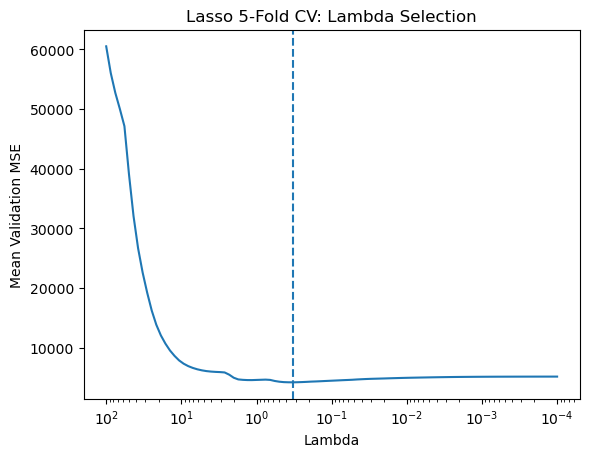

In [10]:
lasso = model.named_steps["lasso_cv"]
alphas = lasso.alphas_
mse_path = lasso.mse_path_
mean_mse = mse_path.mean(axis=1)

plt.figure()
plt.plot(alphas, mean_mse)
plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Mean Validation MSE")
plt.axvline(lasso.alpha_, linestyle="--")
plt.gca().invert_xaxis()
plt.title("Lasso 5-Fold CV: Lambda Selection")
plt.show()

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.3, random_state=42
)
n_trees_list = [1, 5, 10, 50, 100, 200]

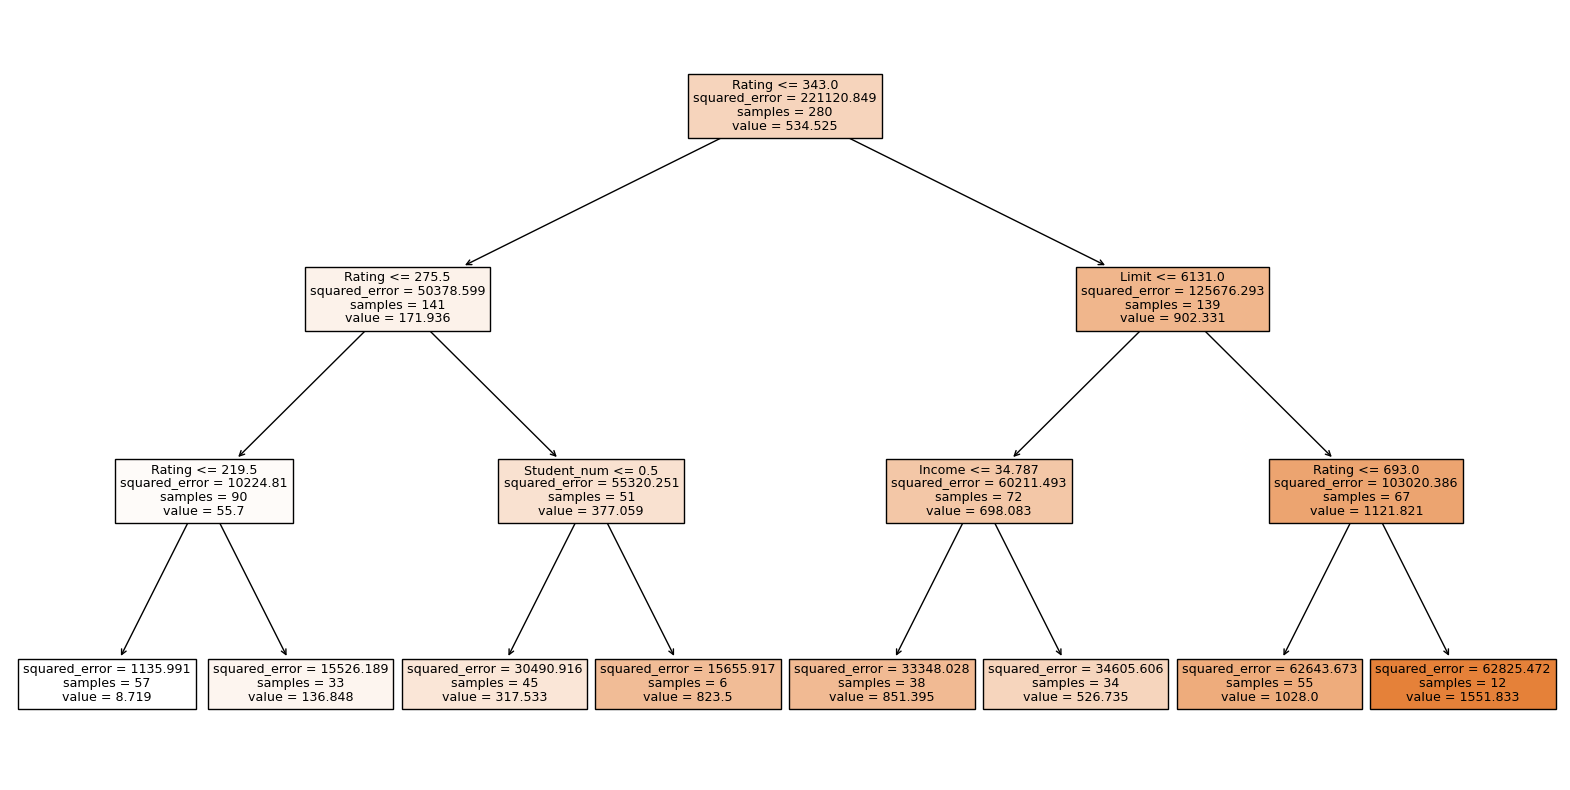

In [31]:
tree = DecisionTreeRegressor(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
mse_tree = mean_squared_error(y_test, y_pred_tree)
plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=list(X.columns), filled=True)
plt.show()

In [32]:
mse_depth3 = []

for n in n_trees_list:
    rf = RandomForestRegressor(
        n_estimators=n,
        max_depth=3,
        random_state=42
    )
    
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    mse_depth3.append(mse)

In [33]:
mse_full = []

for n in n_trees_list:
    rf = RandomForestRegressor(
        n_estimators=n,
        random_state=42
    )
    
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    mse_full.append(mse)

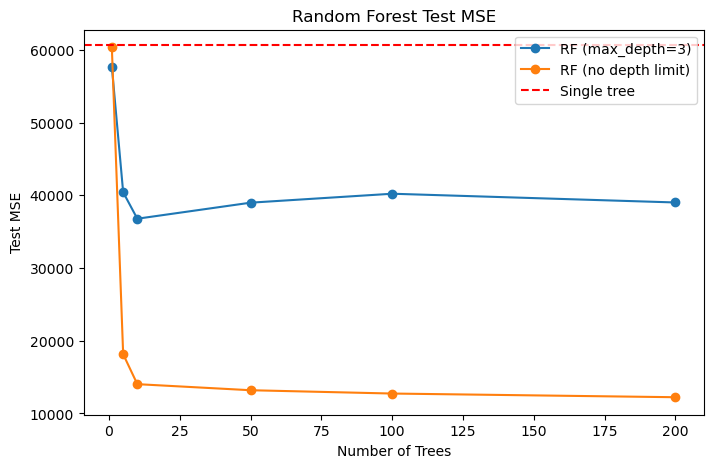

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(n_trees_list, mse_depth3, marker='o', label="RF (max_depth=3)")
plt.plot(n_trees_list, mse_full, marker='o', label="RF (no depth limit)")
plt.axhline(y=mse_tree, color='r', linestyle='--', label="Single tree")

plt.xlabel("Number of Trees")
plt.ylabel("Test MSE")
plt.title("Random Forest Test MSE")
plt.legend()
plt.show()

In [35]:
best_index = np.argmin(mse_full)   # or mse_depth3

best_n = n_trees_list[best_index]
best_mse = mse_full[best_index]

print(best_n, best_mse)

best_rf = RandomForestRegressor(
    n_estimators=best_n,
    random_state=42
)

best_rf.fit(X_train, y_train)

200 12226.330061249999


RandomForestRegressor(n_estimators=200, random_state=42)

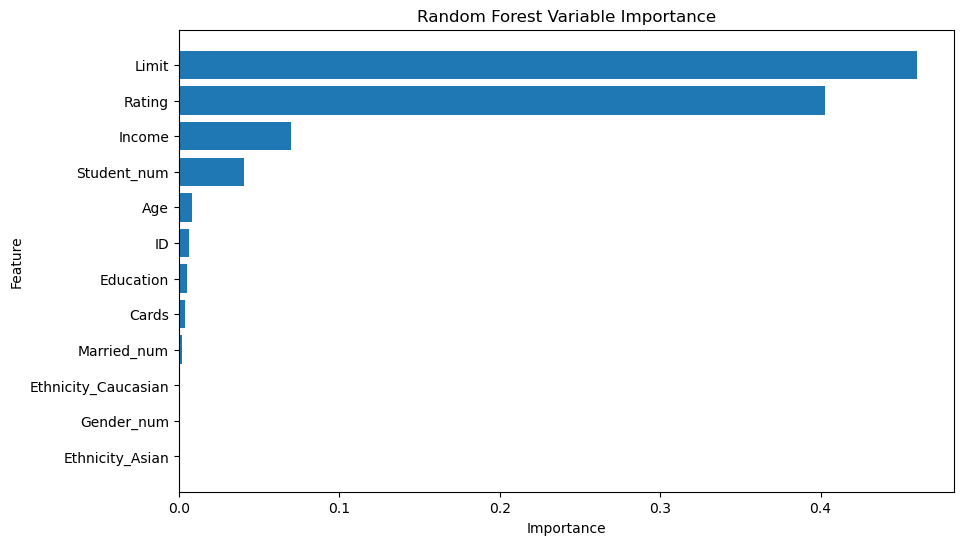

In [36]:
importance_df = pd.DataFrame({
    "Feature": X_raw.columns,
    "Importance": best_rf.feature_importances_
})

importance_df = importance_df.sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Variable Importance")

plt.gca().invert_yaxis()  # most important on top

plt.show()